In [2]:
import laspy
import pandas as pd
import numpy as np
import nbimporter 
from read_plot_voxelization import las_to_dataframe, plot_df_columns


### Rasterizing multispectral point cloud

In [3]:
las_path = "../2025-08-19-MS.laz"
las = laspy.read(las_path)
df = las_to_dataframe(las_path)

print(df.head())
print(df.columns)

print("Scale factors:", las.header.scales)
print("Offsets:", las.header.offsets)
#plot_df_columns(['X', 'Y', 'Z'], df)


📂 Loading LAS file: ../2025-08-19-MS.laz
Number of points: 30,706,449
Detected dimensions: ['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'synthetic', 'key_point', 'withheld', 'overlap', 'scanner_channel', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'user_data', 'scan_angle', 'point_source_id', 'gps_time', 'red', 'green', 'blue', 'nir', 'confidence', 'normal x', 'normal y', 'normal z']
Dataframe create. Shape: (30706449, 26)
        X       Y      Z  intensity  return_number  number_of_returns  \
0  403353  128580  11081          0              1                  1   
1  403353  128580  11081          0              1                  1   
2  403353  128580  11081          0              1                  1   
3  403353  128580  11081          0              1                  1   
4  403353  128580  11081          0              1                  1   

   synthetic  key_point  withheld  overlap  ...  point_source_id  gps_time  \
0          0  

In [4]:
scale = las.header.scales
offset = las.header.offsets
print("Scale factors:", scale)
print("Offsets:", offset)

X_real = las.X * scale[0] + offset[0]
Y_real = las.Y * scale[1] + offset[1]
Z_real = las.Z * scale[2] + offset[2]

coords = np.vstack((X_real, Y_real, Z_real)).T
print(coords[:5])


Scale factors: [1.e-08 1.e-08 1.e-03]
Offsets: [13.61 45.27 30.  ]
[[13.61403353 45.2712858  41.081     ]
 [13.61403353 45.2712858  41.081     ]
 [13.61403353 45.2712858  41.081     ]
 [13.61403353 45.2712858  41.081     ]
 [13.61403353 45.2712858  41.081     ]]


In [5]:
df ['X'] = X_real
df ['Y'] = Y_real
df ['Z'] = Z_real

#plot_df_columns(['X', 'Y', 'Z'], df)

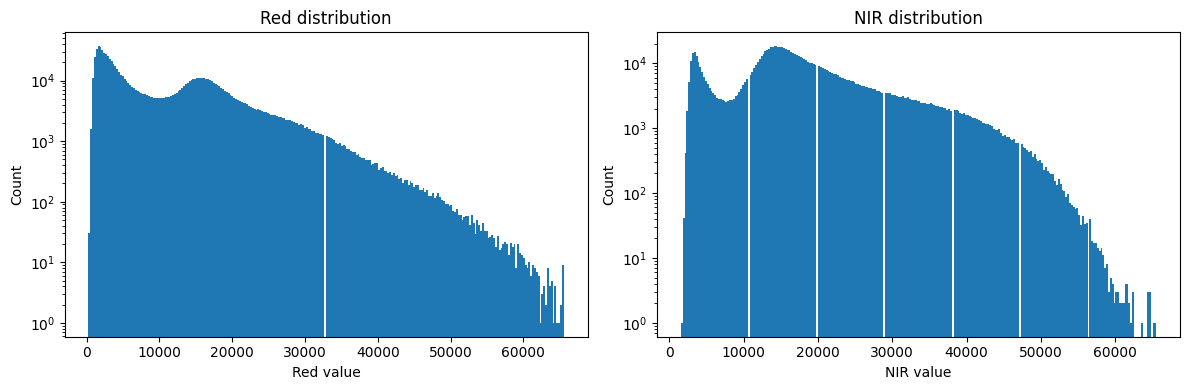

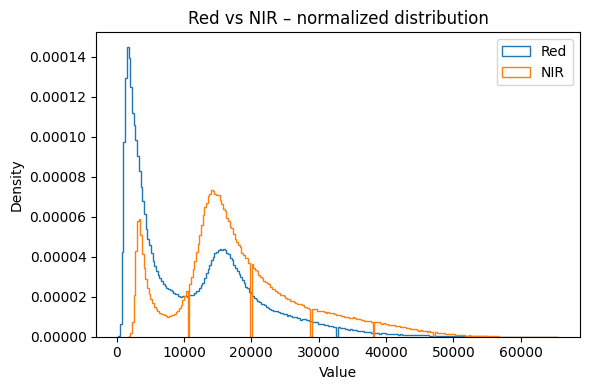

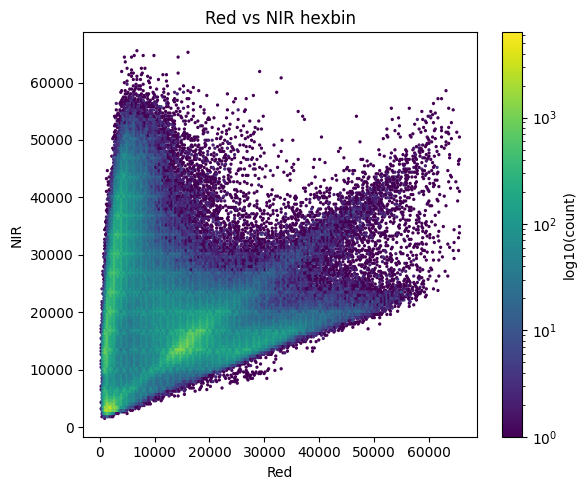

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# --- 0. Optional: subsample (your DF has ~30M rows, plotting all will be slow) ---
max_points = 1_000_000  # adjust if needed
if len(df) > max_points:
    sample = df[['red', 'nir']].sample(n=max_points, random_state=42)
else:
    sample = df[['red', 'nir']].copy()

# --- 1. Separate histograms for red and nir ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sample['red'], bins=256)
axes[0].set_title('Red distribution')
axes[0].set_xlabel('Red value')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')  # log scale helps with long tails; remove if needed

axes[1].hist(sample['nir'], bins=256)
axes[1].set_title('NIR distribution')
axes[1].set_xlabel('NIR value')
axes[1].set_ylabel('Count')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

# --- 2. Overlaid normalized histograms (PDF-style) ---
plt.figure(figsize=(6, 4))

plt.hist(sample['red'], bins=256, density=True, histtype='step', label='Red')
plt.hist(sample['nir'], bins=256, density=True, histtype='step', label='NIR')

plt.title('Red vs NIR – normalized distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

# --- 3. 2D hexbin plot: Red vs NIR (joint distribution) ---
plt.figure(figsize=(6, 5))

plt.hexbin(sample['red'], sample['nir'], gridsize=200, bins='log')
plt.xlabel('Red')
plt.ylabel('NIR')
plt.title('Red vs NIR hexbin')
cb = plt.colorbar()
cb.set_label('log10(count)')

plt.tight_layout()
plt.show()


In [7]:
import numpy as np
import laspy
import rasterio
from rasterio.transform import from_origin

INPUT_FILE = "../2025-08-19-MS.laz"
OUTPUT_TIF = "ndvi_mean_01m.tif"
RESOLUTION = 0.00001      # Note: this is in degrees in your case!
NODATA = -9999.0
CRS_EPSG = None           # e.g., "EPSG:4326" or whatever you use

print("Loading LAS/LAZ:", INPUT_FILE)
las = laspy.read(INPUT_FILE)
print("Total points:", len(las.x))

# 1) Coordinates – convert ScaledArrayView -> numpy
x = np.asarray(las.x, dtype="float64")
y = np.asarray(las.y, dtype="float64")
z = np.asarray(las.z, dtype="float64")

print("Example of 5 coordinates (x, y, z):")
for i in range(5):
    print(f"  {i}: {x[i]:.8f}, {y[i]:.8f}, {z[i]:.3f}")

print("X/Y statistics:")
print("  X min/max:", x.min(), x.max())
print("  Y min/max:", y.min(), y.max())

# 2) Spectral channels – here named 'red' and 'nir'
red = np.asarray(las.red, dtype="float32")
nir = np.asarray(las.nir, dtype="float32")

print("Red statistics:")
print("  red min/max:", red.min(), red.max())
print("NIR statistics:")
print("  nir min/max:", nir.min(), nir.max())

print("Example of 5 red/nir pairs:")
for i in range(5):
    print(f"  {i}: red={red[i]}, nir={nir[i]}")

# 3) NDVI per point
num = nir - red
den = nir + red

ndvi = np.zeros_like(num, dtype="float32")
mask = den != 0

print("Points with den != 0:", mask.sum(), "/", len(mask))

ndvi[mask] = num[mask] / den[mask]

# NDVI statistics
valid_ndvi = ndvi[mask]
print("NDVI statistics (valid points):")
print("  min:", valid_ndvi.min())
print("  max:", valid_ndvi.max())
print("  mean:", valid_ndvi.mean())
print("  std:", valid_ndvi.std())

print("Example 10 NDVI values:", valid_ndvi[:10])

# 4) Raster grid
xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()
dx = xmax - xmin
dy = ymax - ymin

print(f"Extent X: [{xmin}, {xmax}]  ΔX = {dx}")
print(f"Extent Y: [{ymin}, {ymax}]  ΔY = {dy}")
print(f"Resolution used: {RESOLUTION}")

width  = int(np.ceil(dx / RESOLUTION))
height = int(np.ceil(dy / RESOLUTION))

print(f"Raster dimensions (width x height): {width} x {height}")

if width < 5 or height < 5:
    print("WARNING: Raster has very few pixels! "
          "Resolution is likely too large for these coordinates (in degrees).")

# cell indexing
col = ((x - xmin) / RESOLUTION).astype(int)
row = ((ymax - y) / RESOLUTION).astype(int)  # Y axis top-down for raster

valid = (
    (col >= 0) & (col < width) &
    (row >= 0) & (row < height)
)

print("Points inside raster bounds:", valid.sum(), "/", len(valid))

col = col[valid]
row = row[valid]
ndvi_valid_points = ndvi[valid]

Loading LAS/LAZ: ../2025-08-19-MS.laz
Total points: 30706449
Example of 5 coordinates (x, y, z):
  0: 13.61403353, 45.27128580, 41.081
  1: 13.61403353, 45.27128580, 41.081
  2: 13.61403353, 45.27128580, 41.081
  3: 13.61403353, 45.27128580, 41.081
  4: 13.61403353, 45.27128580, 41.081
X/Y statistics:
  X min/max: 13.61386396 13.61547919
  Y min/max: 45.27112763 45.27284506
Red statistics:
  red min/max: 257.0 65535.0
NIR statistics:
  nir min/max: 1542.0 65535.0
Example of 5 red/nir pairs:
  0: red=2827.0, nir=4369.0
  1: red=2827.0, nir=4369.0
  2: red=2827.0, nir=4369.0
  3: red=2827.0, nir=4369.0
  4: red=2827.0, nir=4369.0
Points with den != 0: 30706449 / 30706449
NDVI statistics (valid points):
  min: -0.6
  max: 0.97894734
  mean: 0.28259137
  std: 0.3999001
Example 10 NDVI values: [ 0.21428572  0.21428572  0.21428572  0.21428572  0.21428572  0.21428572
  0.21428572  0.01886792 -0.00787402 -0.01030928]
Extent X: [13.61386396, 13.61547919]  ΔX = 0.0016152300000005226
Extent Y: [4

In [8]:
print(col)
print(row)

[ 16  16  16 ... 161 160 161]
[155 155 155 ...  31  32  31]


In [9]:
print(f"Extent X: [{xmin}, {xmax}]  ΔX = {dx}")
print(f"Extent Y: [{ymin}, {ymax}]  ΔY = {dy}")
print(f"Resolution: {RESOLUTION}")


Extent X: [13.61386396, 13.61547919]  ΔX = 0.0016152300000005226
Extent Y: [45.27112763, 45.27284506]  ΔY = 0.0017174299999993536
Resolution: 1e-05


In [10]:
flat_idx = row * width + col

sum_ndvi = np.bincount(flat_idx, weights=ndvi_valid_points, minlength=width * height)
count = np.bincount(flat_idx, minlength=width * height)

print("Total raster cells:", width * height)
print("Cells that contain at least one point:", (count > 0).sum())

mean_ndvi = np.full(width * height, NODATA, dtype="float32")
nonzero = count > 0
mean_ndvi[nonzero] = sum_ndvi[nonzero] / count[nonzero]

# raster cell statistics
ndvi_cells = mean_ndvi[nonzero]
print("NDVI per raster cell (excluding NODATA):")
print("  min:", ndvi_cells.min())
print("  max:", ndvi_cells.max())
print("  mean:", ndvi_cells.mean())
print("  std:", ndvi_cells.std())

print("Example 20 NDVI cells:", ndvi_cells[:20])

raster = mean_ndvi.reshape((height, width))

# 5) write GeoTIFF
transform = from_origin(xmin, ymax, RESOLUTION, RESOLUTION)

meta = {
    "driver": "GTiff",
    "height": height,
    "width": width,
    "count": 1,
    "dtype": "float32",
    "crs": CRS_EPSG,
    "transform": transform,
    "nodata": NODATA,
}

print("Writing GeoTIFF:", OUTPUT_TIF)
with rasterio.open(OUTPUT_TIF, "w", **meta) as dst:
    dst.write(raster, 1)

print("NDVI raster done:", OUTPUT_TIF)


Total raster cells: 27864
Cells that contain at least one point: 17083
NDVI per raster cell (excluding NODATA):
  min: -0.41286302
  max: 0.9149213
  mean: 0.18769933
  std: 0.27632827
Example 20 NDVI cells: [ 0.07270606 -0.07018286 -0.08807025 -0.05066096 -0.07152481 -0.06276666
 -0.07897542 -0.08751126 -0.08447409 -0.07423034 -0.08367106 -0.13419268
  0.06129068  0.00341639 -0.00070359 -0.0151724  -0.03546472 -0.06981905
  0.34638634  0.24101365]
Writing GeoTIFF: ndvi_mean_01m.tif
NDVI raster done: ndvi_mean_01m.tif
